
# Liver Hepatocytes 3-Class Model-vs-Atlas Comparison

This notebook compares saved liver-hepatocyte model predictions against the liver atlas baseline using three classes defined by configurable low/high cutoffs:

- `close_to_0`: `label <= p_low`
- `middle`: `p_low < label < p_high`
- `close_to_1`: `label >= p_high`

For each saved run we:

1. select the final `epoch-*` prediction file,
2. join it with the held-out sample's atlas reference,
3. classify labels, model predictions, and atlas predictions using configurable quantile or fixed thresholds,
4. save row-level classified data,
5. compute paired model-vs-atlas metrics and visualizations.


In [7]:

from __future__ import annotations

import gc
import math
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

REPO_ROOT = Path("/cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code")
NOTEBOOK_ROOT = REPO_ROOT / "notebooks"
SRC_ROOT = REPO_ROOT / "src"

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from src.utils.atlas_bigwig_utils import build_atlas_position_dataframe
from src.utils.atlas_distribution_utils import resolve_group_bigwig_paths

# RUNS_ROOT = Path("/sci/labs/michall/roeizucker/_kol_kora_high_only_Liver-Hepatocytes_kmer_2")
RUNS_ROOT = Path("/sci/labs/michall/roeizucker/copy_old_models/_kol_kora_no_var_Liver-Hepatocytes_window/_kol_kora_no_var_Liver-Hepatocytes_window/")
RESULTS_ROOT = NOTEBOOK_ROOT / "results" / "liver_hepatocytes_percentile_classification_comparison"
ATLAS_REFERENCE_DIR = RESULTS_ROOT / "atlas_reference"
CLASSIFIED_ROWS_DIR = RESULTS_ROOT / "classified_rows"
FIGURES_DIR = RESULTS_ROOT / "figures"

for output_dir in [RESULTS_ROOT, ATLAS_REFERENCE_DIR, CLASSIFIED_ROWS_DIR, FIGURES_DIR]:
    output_dir.mkdir(parents=True, exist_ok=True)

UBER_SCRIPT_PATH = SRC_ROOT / "uber_project_creator_script.py"
TISSUE_GROUP_NAME = "Liver-Hepatocytes"
CLASS_LABELS = ["close_to_0", "middle", "close_to_1"]
CLASS_COLOR_MAP = {
    "close_to_0": "#4C78A8",
    "middle": "#F58518",
    "close_to_1": "#54A24B",
}
SOURCE_COLOR_MAP = {
    "model": "#4C78A8",
    "atlas": "#E45756",
}
TRAINING_REGIME_ORDER = ["epoch-1", "epoch-2", "no_pretraining"]
# THRESHOLD_METHOD = "quantile"  # choose "quantile" or "fixed"
THRESHOLD_METHOD = "fixed"  # choose "quantile" or "fixed"
THRESHOLD_SCOPE = "global"  # only used when THRESHOLD_METHOD == "quantile"; choose "local" or "global"
LOW_QUANTILE = 0.05
HIGH_QUANTILE = 0.90
FIXED_P_LOW = 0.20
FIXED_P_HIGH = 0.80
EXPECTED_RUN_COUNT = None  # set to an integer if you want a strict manifest-size check
CHROMOSOMES = [
    # "chr1",
    # "chr2",
    # "chr3",
    "chr4",
    "chr5",
]

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")
pd.options.display.max_columns = 200
pd.options.display.float_format = lambda value: f"{value:0.6f}"

print(f"RUNS_ROOT: {RUNS_ROOT}")
print(f"RESULTS_ROOT: {RESULTS_ROOT}")


RUNS_ROOT: /sci/labs/michall/roeizucker/copy_old_models/_kol_kora_no_var_Liver-Hepatocytes_window/_kol_kora_no_var_Liver-Hepatocytes_window
RESULTS_ROOT: /cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/liver_hepatocytes_percentile_classification_comparison


In [8]:

RUN_DIR_RE = re.compile(
    r"^(?P<held_out_sample>Z[0-9A-Z]+)_(?P<pretraining_source>epoch-\d+-step-\d+|no_pretraining)"
    r"_retrain_(?P<run_family>.+?)_lr_(?P<lr>[^_]+)_bs_(?P<batch_size>[^_]+)"
    r"_seq_(?P<seq_len>\d+)_testsize_(?P<test_size>[^_]+)$"
)
EPOCH_DIR_RE = re.compile(r"^epoch-(?P<epoch>\d+)-step-(?P<step>\d+)$")


def training_regime_from_source(pretraining_source: str) -> str:
    if pretraining_source == "no_pretraining":
        return "no_pretraining"
    if pretraining_source.startswith("epoch-1-"):
        return "epoch-1"
    if pretraining_source.startswith("epoch-2-"):
        return "epoch-2"
    raise ValueError(f"Unsupported pretraining source: {pretraining_source}")


def find_final_prediction_file(run_dir: Path) -> tuple[Path, str, int, int]:
    epoch_candidates: list[tuple[int, int, str, Path]] = []
    for child in run_dir.iterdir():
        if not child.is_dir() or child.name.startswith("checkpoint"):
            continue
        match = EPOCH_DIR_RE.match(child.name)
        if match is None:
            continue
        prediction_path = child / "eval_predictions.csv.gitbackup"
        if not prediction_path.exists():
            continue
        epoch_candidates.append(
            (
                int(match.group("epoch")),
                int(match.group("step")),
                child.name,
                prediction_path,
            )
        )
    if not epoch_candidates:
        raise FileNotFoundError(f"No final epoch prediction file found in {run_dir}")
    final_epoch, final_step, final_epoch_name, prediction_path = max(epoch_candidates, key=lambda item: (item[0], item[1]))
    return prediction_path, final_epoch_name, final_epoch, final_step


def build_run_manifest(runs_root: Path) -> pd.DataFrame:
    manifest_rows: list[dict[str, object]] = []
    for run_dir in sorted(path for path in runs_root.iterdir() if path.is_dir()):
        match = RUN_DIR_RE.match(run_dir.name)
        if match is None:
            continue
        prediction_path, final_epoch_name, final_epoch, final_step = find_final_prediction_file(run_dir)
        pretraining_source = match.group("pretraining_source")
        manifest_rows.append(
            {
                "run_id": run_dir.name,
                "held_out_sample": match.group("held_out_sample"),
                "pretraining_source": pretraining_source,
                "training_regime": training_regime_from_source(pretraining_source),
                "seq_len": int(match.group("seq_len")),
                "run_family": match.group("run_family"),
                "lr": match.group("lr"),
                "batch_size": int(match.group("batch_size")),
                "test_size": float(match.group("test_size")),
                "run_dir": str(run_dir),
                "prediction_path": str(prediction_path),
                "final_epoch_name": final_epoch_name,
                "final_epoch": final_epoch,
                "final_step": final_step,
                "classified_rows_path": str(CLASSIFIED_ROWS_DIR / f"{run_dir.name}.csv.gz"),
                "atlas_reference_path": str(ATLAS_REFERENCE_DIR / f"{match.group('held_out_sample')}_atlas_reference.csv.gz"),
            }
        )

    manifest_df = pd.DataFrame(manifest_rows)
    if manifest_df.empty:
        raise RuntimeError(f"No matching run directories were found under {runs_root}")

    manifest_df = manifest_df.sort_values(
        by=["held_out_sample", "seq_len", "training_regime", "final_epoch", "final_step", "run_id"]
    ).reset_index(drop=True)
    return manifest_df


def read_prediction_table(prediction_path: Path) -> pd.DataFrame:
    prediction_df = pd.read_csv(
        prediction_path,
        usecols=["window_id", "genomic_position", "label", "prediction"],
        dtype={
            "window_id": "string",
            "genomic_position": "int64",
            "label": "float32",
            "prediction": "float32",
        },
    )
    prediction_df["chrom"] = prediction_df["window_id"].str.split(":", n=1).str[0]
    prediction_df["full_position"] = (
        prediction_df["chrom"].astype("string")
        + ":"
        + prediction_df["genomic_position"].astype("string")
        + "-"
        + (prediction_df["genomic_position"] + 2).astype("string")
    )
    if not prediction_df["full_position"].is_unique:
        duplicate_count = int(prediction_df["full_position"].duplicated().sum())
        raise ValueError(f"Prediction file {prediction_path} contains {duplicate_count} duplicated positions")
    return prediction_df[["full_position", "label", "prediction"]].rename(columns={"prediction": "model_prediction"})


def build_or_load_atlas_reference(sample_id: str) -> pd.DataFrame:
    atlas_reference_path = ATLAS_REFERENCE_DIR / f"{sample_id}_atlas_reference.csv.gz"
    if atlas_reference_path.exists():
        atlas_reference_df = pd.read_csv(
            atlas_reference_path,
            dtype={
                "full_position": "string",
                "target_value": "float32",
                "atlas_mean": "float32",
                "std": "float32",
            },
        )
        if not atlas_reference_df["full_position"].is_unique:
            raise ValueError(f"Atlas reference cache {atlas_reference_path} contains duplicate positions")
        return atlas_reference_df

    resolved = resolve_group_bigwig_paths(
        group_name=TISSUE_GROUP_NAME,
        held_out_sample=sample_id,
        uber_script_path=UBER_SCRIPT_PATH,
    )
    atlas_reference_df = build_atlas_position_dataframe(
        target_bigwig_path=resolved["target_bigwig_path"],
        atlas_bigwig_paths=resolved["atlas_bigwig_paths"],
        number_of_bins=5,
        chroms=CHROMOSOMES,
        top_rows=-1,
        test_mode=False,
        jump_sample=-1,
        verbose=True,
    )
    if atlas_reference_df.empty:
        raise RuntimeError(f"Atlas reference for {sample_id} is empty")
    atlas_reference_df = atlas_reference_df[["full_position", "target_value", "atlas_mean", "std"]].copy()
    atlas_reference_df["target_value"] = atlas_reference_df["target_value"].astype("float32")
    atlas_reference_df["atlas_mean"] = atlas_reference_df["atlas_mean"].astype("float32")
    atlas_reference_df["std"] = atlas_reference_df["std"].astype("float32")
    atlas_reference_df.to_csv(atlas_reference_path, index=False, compression="gzip")
    return atlas_reference_df


def classify_series(values: pd.Series, p_low: float, p_high: float) -> pd.Categorical:
    classified = np.select(
        [values <= p_low, values >= p_high],
        ["close_to_0", "close_to_1"],
        default="middle",
    )
    return pd.Categorical(classified, categories=CLASS_LABELS, ordered=True)


def compute_threshold_pair(values: pd.Series) -> tuple[float, float]:
    clean_values = pd.Series(values).dropna()
    return (
        float(clean_values.quantile(LOW_QUANTILE)),
        float(clean_values.quantile(HIGH_QUANTILE)),
    )


def compute_global_threshold_pair(run_manifest_df: pd.DataFrame) -> tuple[float, float]:
    all_label_values: list[pd.Series] = []
    for sample_id in sorted(run_manifest_df["held_out_sample"].unique()):
        atlas_reference_df = build_or_load_atlas_reference(str(sample_id))
        all_label_values.append(atlas_reference_df["target_value"])
    global_labels = pd.concat(all_label_values, ignore_index=True)
    return compute_threshold_pair(global_labels)


def compute_fixed_threshold_pair() -> tuple[float, float]:
    p_low = float(FIXED_P_LOW)
    p_high = float(FIXED_P_HIGH)
    if not (0.0 <= p_low <= p_high <= 1.0):
        raise ValueError(f"Fixed thresholds must satisfy 0 <= p_low <= p_high <= 1, got {p_low} and {p_high}")
    return p_low, p_high


def compute_metric_records(
    y_true: pd.Series,
    y_pred: pd.Series,
    base_metadata: dict[str, object],
    source: str,
) -> tuple[dict[str, object], list[dict[str, object]], list[dict[str, object]], np.ndarray]:
    precision_values, recall_values, f1_values, support_values = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=CLASS_LABELS,
        zero_division=0,
    )
    confusion = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)

    overall_record = {
        **base_metadata,
        "source": source,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, labels=CLASS_LABELS, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, labels=CLASS_LABELS, average="weighted", zero_division=0)),
    }

    per_class_records: list[dict[str, object]] = []
    confusion_records: list[dict[str, object]] = []

    for class_index, class_label in enumerate(CLASS_LABELS):
        per_class_records.append(
            {
                **base_metadata,
                "source": source,
                "class_label": class_label,
                "precision": float(precision_values[class_index]),
                "recall": float(recall_values[class_index]),
                "f1": float(f1_values[class_index]),
                "support": int(support_values[class_index]),
            }
        )

        row_total = int(confusion[class_index].sum())
        for pred_index, predicted_label in enumerate(CLASS_LABELS):
            count_value = int(confusion[class_index, pred_index])
            confusion_records.append(
                {
                    **base_metadata,
                    "source": source,
                    "true_class": class_label,
                    "pred_class": predicted_label,
                    "count": count_value,
                    "row_fraction": float(count_value / row_total) if row_total else np.nan,
                }
            )

    return overall_record, per_class_records, confusion_records, confusion


def make_group_label(seq_len: int, training_regime: str) -> str:
    return f"seq {seq_len}\n{training_regime}"


In [9]:

run_manifest_df = build_run_manifest(RUNS_ROOT)
if EXPECTED_RUN_COUNT is not None:
    assert len(run_manifest_df) == EXPECTED_RUN_COUNT, f"Expected {EXPECTED_RUN_COUNT} run folders, found {len(run_manifest_df)}"
assert run_manifest_df["prediction_path"].nunique() == len(run_manifest_df), "Prediction file discovery did not find one unique final file per discovered run"
run_manifest_df.to_csv(RESULTS_ROOT / "run_manifest.csv", index=False)
print(f"Discovered {len(run_manifest_df)} run folders and {run_manifest_df['prediction_path'].nunique()} final prediction files")
run_manifest_df.head()


Discovered 18 run folders and 18 final prediction files


,run_id,held_out_sample,pretraining_source,training_regime,seq_len,run_family,lr,batch_size,test_size,run_dir,prediction_path,final_epoch_name,final_epoch,final_step,classified_rows_path,atlas_reference_path
0,Z000000R3_epoch-1-step-11623_retrain_kol_kora_...,Z000000R3,epoch-1-step-11623,epoch-1,5400,kol_kora_no_var_Liver-Hepatocytes_window,1e-06,64,0.200000,/sci/labs/michall/roeizucker/copy_old_models/_...,/sci/labs/michall/roeizucker/copy_old_models/_...,epoch-5-step-9295,5,9295,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,/cs/usr/roeizucker/new_storage/jupyter_noteboo...
1,Z000000R3_epoch-2-step-23246_retrain_kol_kora_...,Z000000R3,epoch-2-step-23246,epoch-2,5400,kol_kora_no_var_Liver-Hepatocytes_window,1e-06,64,0.200000,/sci/labs/michall/roeizucker/copy_old_models/_...,/sci/labs/michall/roeizucker/copy_old_models/_...,epoch-5-step-9295,5,9295,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,/cs/usr/roeizucker/new_storage/jupyter_noteboo...
2,Z000000R3_no_pretraining_retrain_kol_kora_no_v...,Z000000R3,no_pretraining,no_pretraining,5400,kol_kora_no_var_Liver-Hepatocytes_window,1e-06,64,0.200000,/sci/labs/michall/roeizucker/copy_old_models/_...,/sci/labs/michall/roeizucker/copy_old_models/_...,epoch-5-step-9295,5,9295,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,/cs/usr/roeizucker/new_storage/jupyter_noteboo...
3,Z000000T3_epoch-1-step-11621_retrain_kol_kora_...,Z000000T3,epoch-1-step-11621,epoch-1,5400,kol_kora_no_var_Liver-Hepatocytes_window,1e-06,64,0.200000,/sci/labs/michall/roeizucker/copy_old_models/_...,/sci/labs/michall/roeizucker/copy_old_models/_...,epoch-5-step-9295,5,9295,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,/cs/usr/roeizucker/new_storage/jupyter_noteboo...
4,Z000000T3_epoch-2-step-23242_retrain_kol_kora_...,Z000000T3,epoch-2-step-23242,epoch-2,5400,kol_kora_no_var_Liver-Hepatocytes_window,1e-06,64,0.200000,/sci/labs/michall/roeizucker/copy_old_models/_...,/sci/labs/michall/roeizucker/copy_old_models/_...,epoch-5-step-9295,5,9295,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,/cs/usr/roeizucker/new_storage/jupyter_noteboo...


In [10]:

atlas_reference_rows: list[dict[str, object]] = []
for sample_id in sorted(run_manifest_df["held_out_sample"].unique()):
    atlas_reference_df = build_or_load_atlas_reference(sample_id)
    atlas_reference_rows.append(
        {
            "held_out_sample": sample_id,
            "atlas_reference_path": str(ATLAS_REFERENCE_DIR / f"{sample_id}_atlas_reference.csv.gz"),
            "row_count": int(len(atlas_reference_df)),
        }
    )
    print(f"Atlas reference ready for {sample_id}: {len(atlas_reference_df):,} rows")
    del atlas_reference_df
    gc.collect()

atlas_reference_manifest_df = pd.DataFrame(atlas_reference_rows).sort_values("held_out_sample").reset_index(drop=True)
assert atlas_reference_manifest_df["row_count"].gt(0).all(), "One or more atlas references are empty"
atlas_reference_manifest_df


Atlas reference ready for Z000000R3: 11,307,327 rows
Atlas reference ready for Z000000T3: 11,307,327 rows
Atlas reference ready for Z00000431: 11,307,327 rows
Atlas reference ready for Z0000043Q: 11,307,327 rows
Atlas reference ready for Z0000044H: 11,307,327 rows
Atlas reference ready for Z0000044M: 11,307,327 rows


,held_out_sample,atlas_reference_path,row_count
0,Z000000R3,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,11307327
1,Z000000T3,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,11307327
2,Z00000431,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,11307327
3,Z0000043Q,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,11307327
4,Z0000044H,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,11307327
5,Z0000044M,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,11307327


In [11]:

metrics_rows: list[dict[str, object]] = []
per_class_rows: list[dict[str, object]] = []
confusion_rows: list[dict[str, object]] = []

overall_label_support = Counter()
overall_confusion_totals = {
    "model": np.zeros((len(CLASS_LABELS), len(CLASS_LABELS)), dtype=np.int64),
    "atlas": np.zeros((len(CLASS_LABELS), len(CLASS_LABELS)), dtype=np.int64),
}

current_sample_id: str | None = None
current_atlas_reference_df: pd.DataFrame | None = None

if THRESHOLD_METHOD not in {"quantile", "fixed"}:
    raise ValueError(f"Unsupported THRESHOLD_METHOD: {THRESHOLD_METHOD}")
if THRESHOLD_METHOD == "quantile" and THRESHOLD_SCOPE not in {"local", "global"}:
    raise ValueError(f"Unsupported THRESHOLD_SCOPE: {THRESHOLD_SCOPE}")

global_p_low: float | None = None
global_p_high: float | None = None
if THRESHOLD_METHOD == "quantile" and THRESHOLD_SCOPE == "global":
    global_p_low, global_p_high = compute_global_threshold_pair(run_manifest_df)
    print(f"Using global quantile thresholds | p_low={global_p_low:0.5f} | p_high={global_p_high:0.5f}")
elif THRESHOLD_METHOD == "fixed":
    global_p_low, global_p_high = compute_fixed_threshold_pair()
    print(f"Using fixed thresholds | p_low={global_p_low:0.5f} | p_high={global_p_high:0.5f}")

for run_row in run_manifest_df.to_dict(orient="records"):
    sample_id = str(run_row["held_out_sample"])
    if sample_id != current_sample_id:
        current_atlas_reference_df = pd.read_csv(
            ATLAS_REFERENCE_DIR / f"{sample_id}_atlas_reference.csv.gz",
            dtype={
                "full_position": "string",
                "target_value": "float32",
                "atlas_mean": "float32",
                "std": "float32",
            },
        )
        assert current_atlas_reference_df["full_position"].is_unique, f"Atlas reference for {sample_id} contains duplicate positions"
        current_sample_id = sample_id
        print(f"Loaded atlas reference for {sample_id}: {len(current_atlas_reference_df):,} rows")

    prediction_df = read_prediction_table(Path(str(run_row["prediction_path"])))
    assert prediction_df["full_position"].is_unique, f"Prediction table {run_row['prediction_path']} contains duplicate positions"

    merged_df = prediction_df.merge(
        current_atlas_reference_df,
        on="full_position",
        how="inner",
        validate="one_to_one",
    )
    if merged_df.empty:
        raise RuntimeError(f"Join with atlas reference produced zero rows for run {run_row['run_id']}")

    if THRESHOLD_METHOD == "quantile":
        if THRESHOLD_SCOPE == "local":
            p_low, p_high = compute_threshold_pair(merged_df["label"])
        else:
            assert global_p_low is not None and global_p_high is not None
            p_low, p_high = global_p_low, global_p_high
    else:
        assert global_p_low is not None and global_p_high is not None
        p_low, p_high = global_p_low, global_p_high
    assert p_low <= p_high, f"Percentile thresholds are not monotonic for run {run_row['run_id']}"

    merged_df["label_class"] = classify_series(merged_df["label"], p_low, p_high)
    merged_df["model_class"] = classify_series(merged_df["model_prediction"], p_low, p_high)
    merged_df["atlas_class"] = classify_series(merged_df["atlas_mean"], p_low, p_high)

    if merged_df["label_class"].isna().any() or merged_df["model_class"].isna().any() or merged_df["atlas_class"].isna().any():
        raise ValueError(f"Null class assignment detected for run {run_row['run_id']}")

    label_class_values = set(merged_df["label_class"].astype(str).unique())
    model_class_values = set(merged_df["model_class"].astype(str).unique())
    atlas_class_values = set(merged_df["atlas_class"].astype(str).unique())
    expected_class_values = set(CLASS_LABELS)
    assert label_class_values.issubset(expected_class_values)
    assert model_class_values.issubset(expected_class_values)
    assert atlas_class_values.issubset(expected_class_values)

    label_vs_atlas_target_abs_diff = (merged_df["label"] - merged_df["target_value"]).abs()

    base_metadata = {
        "run_id": run_row["run_id"],
        "held_out_sample": sample_id,
        "training_regime": run_row["training_regime"],
        "pretraining_source": run_row["pretraining_source"],
        "seq_len": int(run_row["seq_len"]),
        "lr": run_row["lr"],
        "batch_size": int(run_row["batch_size"]),
        "test_size": float(run_row["test_size"]),
        "prediction_path": run_row["prediction_path"],
        "final_epoch_name": run_row["final_epoch_name"],
        "final_epoch": int(run_row["final_epoch"]),
        "final_step": int(run_row["final_step"]),
        "classified_rows_path": run_row["classified_rows_path"],
        "atlas_reference_path": run_row["atlas_reference_path"],
        "overlap_count": int(len(merged_df)),
        "threshold_method": THRESHOLD_METHOD,
        "threshold_scope": THRESHOLD_SCOPE if THRESHOLD_METHOD == "quantile" else "fixed",
        "threshold_low_quantile": LOW_QUANTILE if THRESHOLD_METHOD == "quantile" else np.nan,
        "threshold_high_quantile": HIGH_QUANTILE if THRESHOLD_METHOD == "quantile" else np.nan,
        "label_p_low": p_low,
        "label_p_high": p_high,
        "label_vs_atlas_target_mae": float(label_vs_atlas_target_abs_diff.mean()),
        "label_vs_atlas_target_max_abs_diff": float(label_vs_atlas_target_abs_diff.max()),
    }

    classified_output_df = merged_df[
        [
            "full_position",
            "label",
            "model_prediction",
            "atlas_mean",
            "target_value",
            "std",
            "label_class",
            "model_class",
            "atlas_class",
        ]
    ].rename(columns={"atlas_mean": "atlas_prediction", "target_value": "atlas_target_value"}).copy()

    classified_output_df.insert(0, "run_id", base_metadata["run_id"])
    classified_output_df.insert(1, "held_out_sample", base_metadata["held_out_sample"])
    classified_output_df.insert(2, "training_regime", base_metadata["training_regime"])
    classified_output_df.insert(3, "seq_len", base_metadata["seq_len"])
    classified_output_df.insert(4, "label_p_low", base_metadata["label_p_low"])
    classified_output_df.insert(5, "label_p_high", base_metadata["label_p_high"])
    classified_output_df.to_csv(run_row["classified_rows_path"], index=False, compression="gzip")

    for class_label in CLASS_LABELS:
        overall_label_support[class_label] += int((merged_df["label_class"].astype(str) == class_label).sum())

    for source_name, predicted_column in [("model", "model_class"), ("atlas", "atlas_class")]:
        overall_record, source_per_class_rows, source_confusion_rows, confusion_values = compute_metric_records(
            merged_df["label_class"].astype(str),
            merged_df[predicted_column].astype(str),
            base_metadata,
            source_name,
        )
        metrics_rows.append(overall_record)
        per_class_rows.extend(source_per_class_rows)
        confusion_rows.extend(source_confusion_rows)
        overall_confusion_totals[source_name] += confusion_values

    print(
        f"Processed {run_row['run_id']} | overlap={len(merged_df):,} | p_low={p_low:0.5f} | p_high={p_high:0.5f}"
    )

    del prediction_df
    del merged_df
    del classified_output_df
    gc.collect()

metrics_by_run_df = pd.DataFrame(metrics_rows).sort_values(["run_id", "source"]).reset_index(drop=True)
per_class_metrics_df = pd.DataFrame(per_class_rows).sort_values(["run_id", "source", "class_label"]).reset_index(drop=True)
confusion_counts_df = pd.DataFrame(confusion_rows).sort_values(["run_id", "source", "true_class", "pred_class"]).reset_index(drop=True)

assert len(metrics_by_run_df) == len(run_manifest_df) * 2, "metrics_by_run.csv does not contain one row per run per source"
assert set(metrics_by_run_df["source"].unique()) == {"model", "atlas"}
assert per_class_metrics_df["class_label"].isin(CLASS_LABELS).all()
assert confusion_counts_df["true_class"].isin(CLASS_LABELS).all()
assert confusion_counts_df["pred_class"].isin(CLASS_LABELS).all()

metrics_by_run_df.to_csv(RESULTS_ROOT / "metrics_by_run.csv", index=False)
per_class_metrics_df.to_csv(RESULTS_ROOT / "per_class_metrics.csv", index=False)
confusion_counts_df.to_csv(RESULTS_ROOT / "confusion_counts.csv", index=False)

metrics_by_run_df.head()


Using fixed thresholds | p_low=0.20000 | p_high=0.80000
Loaded atlas reference for Z000000R3: 11,307,327 rows
Processed Z000000R3_epoch-1-step-11623_retrain_kol_kora_no_var_Liver-Hepatocytes_window_lr_1e-06_bs_64_seq_5400_testsize_0.2 | overlap=45,658 | p_low=0.20000 | p_high=0.80000
Processed Z000000R3_epoch-2-step-23246_retrain_kol_kora_no_var_Liver-Hepatocytes_window_lr_1e-06_bs_64_seq_5400_testsize_0.2 | overlap=45,658 | p_low=0.20000 | p_high=0.80000
Processed Z000000R3_no_pretraining_retrain_kol_kora_no_var_Liver-Hepatocytes_window_lr_1e-06_bs_64_seq_5400_testsize_0.2 | overlap=45,658 | p_low=0.20000 | p_high=0.80000
Loaded atlas reference for Z000000T3: 11,307,327 rows
Processed Z000000T3_epoch-1-step-11621_retrain_kol_kora_no_var_Liver-Hepatocytes_window_lr_1e-06_bs_64_seq_5400_testsize_0.2 | overlap=45,104 | p_low=0.20000 | p_high=0.80000
Processed Z000000T3_epoch-2-step-23242_retrain_kol_kora_no_var_Liver-Hepatocytes_window_lr_1e-06_bs_64_seq_5400_testsize_0.2 | overlap=45,10

,run_id,held_out_sample,training_regime,pretraining_source,seq_len,lr,batch_size,test_size,prediction_path,final_epoch_name,final_epoch,final_step,classified_rows_path,atlas_reference_path,overlap_count,threshold_method,threshold_scope,threshold_low_quantile,threshold_high_quantile,label_p_low,label_p_high,label_vs_atlas_target_mae,label_vs_atlas_target_max_abs_diff,source,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Z000000R3_epoch-1-step-11623_retrain_kol_kora_...,Z000000R3,epoch-1,epoch-1-step-11623,5400,1e-06,64,0.200000,/sci/labs/michall/roeizucker/copy_old_models/_...,epoch-5-step-9295,5,9295,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,45658,fixed,fixed,NaN,NaN,0.200000,0.800000,0.002180,0.478256,atlas,0.861098,0.787951,0.797371,0.862169
1,Z000000R3_epoch-1-step-11623_retrain_kol_kora_...,Z000000R3,epoch-1,epoch-1-step-11623,5400,1e-06,64,0.200000,/sci/labs/michall/roeizucker/copy_old_models/_...,epoch-5-step-9295,5,9295,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,45658,fixed,fixed,NaN,NaN,0.200000,0.800000,0.002180,0.478256,model,0.740527,0.611759,0.644945,0.745374
2,Z000000R3_epoch-2-step-23246_retrain_kol_kora_...,Z000000R3,epoch-2,epoch-2-step-23246,5400,1e-06,64,0.200000,/sci/labs/michall/roeizucker/copy_old_models/_...,epoch-5-step-9295,5,9295,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,45658,fixed,fixed,NaN,NaN,0.200000,0.800000,0.002180,0.478256,atlas,0.861098,0.787951,0.797371,0.862169
3,Z000000R3_epoch-2-step-23246_retrain_kol_kora_...,Z000000R3,epoch-2,epoch-2-step-23246,5400,1e-06,64,0.200000,/sci/labs/michall/roeizucker/copy_old_models/_...,epoch-5-step-9295,5,9295,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,45658,fixed,fixed,NaN,NaN,0.200000,0.800000,0.002180,0.478256,model,0.769241,0.639841,0.676230,0.771457
4,Z000000R3_no_pretraining_retrain_kol_kora_no_v...,Z000000R3,no_pretraining,no_pretraining,5400,1e-06,64,0.200000,/sci/labs/michall/roeizucker/copy_old_models/_...,epoch-5-step-9295,5,9295,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,/cs/usr/roeizucker/new_storage/jupyter_noteboo...,45658,fixed,fixed,NaN,NaN,0.200000,0.800000,0.002180,0.478256,atlas,0.861098,0.787951,0.797371,0.862169


In [12]:

group_summary_rows: list[dict[str, object]] = []
for (seq_len, training_regime), group_df in metrics_by_run_df.groupby(["seq_len", "training_regime"], sort=True):
    group_record = {
        "seq_len": int(seq_len),
        "training_regime": training_regime,
        "group_label": make_group_label(int(seq_len), training_regime),
        "n_runs": int(group_df["run_id"].nunique()),
    }
    for metric_name in ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]:
        model_values = group_df.loc[group_df["source"] == "model", metric_name].astype(float)
        atlas_values = group_df.loc[group_df["source"] == "atlas", metric_name].astype(float)
        group_record[f"model_mean_{metric_name}"] = float(model_values.mean())
        group_record[f"atlas_mean_{metric_name}"] = float(atlas_values.mean())
        group_record[f"model_std_{metric_name}"] = float(model_values.std(ddof=1)) if len(model_values) > 1 else 0.0
        group_record[f"atlas_std_{metric_name}"] = float(atlas_values.std(ddof=1)) if len(atlas_values) > 1 else 0.0
        group_record[f"delta_model_minus_atlas_{metric_name}"] = (
            group_record[f"model_mean_{metric_name}"] - group_record[f"atlas_mean_{metric_name}"]
        )
    group_summary_rows.append(group_record)

group_summary_df = pd.DataFrame(group_summary_rows)
group_summary_df["training_regime"] = pd.Categorical(
    group_summary_df["training_regime"],
    categories=TRAINING_REGIME_ORDER,
    ordered=True,
)
group_summary_df = group_summary_df.sort_values(["seq_len", "training_regime"]).reset_index(drop=True)
group_summary_df.to_csv(RESULTS_ROOT / "group_summary.csv", index=False)

support_df = pd.DataFrame(
    {
        "class_label": CLASS_LABELS,
        "count": [int(overall_label_support[class_label]) for class_label in CLASS_LABELS],
    }
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(
    support_df["class_label"],
    support_df["count"],
    color=[CLASS_COLOR_MAP[class_label] for class_label in support_df["class_label"]],
)
ax.set_title("Overall label-class support across all joined runs")
ax.set_xlabel("Label class")
ax.set_ylabel("Row count")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "overall_label_class_support.png", dpi=150, bbox_inches="tight")
plt.close(fig)

scatter_df = metrics_by_run_df.pivot_table(
    index=["run_id", "held_out_sample", "seq_len", "training_regime"],
    columns="source",
    values="macro_f1",
    aggfunc="first",
).reset_index()
scatter_df.columns.name = None

fig, ax = plt.subplots(figsize=(7, 6))
for seq_len in sorted(scatter_df["seq_len"].unique()):
    seq_subset = scatter_df[scatter_df["seq_len"] == seq_len]
    ax.scatter(
        seq_subset["atlas"],
        seq_subset["model"],
        s=65,
        alpha=0.8,
        label=f"seq {seq_len}",
    )
min_value = float(min(scatter_df["atlas"].min(), scatter_df["model"].min()))
max_value = float(max(scatter_df["atlas"].max(), scatter_df["model"].max()))
ax.plot([min_value, max_value], [min_value, max_value], linestyle="--", color="black", linewidth=1)
ax.set_title("Run-level macro-F1: atlas vs model")
ax.set_xlabel("Atlas macro-F1")
ax.set_ylabel("Model macro-F1")
ax.legend(title="Sequence length")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "macro_f1_model_vs_atlas_scatter.png", dpi=150, bbox_inches="tight")
plt.close(fig)

plot_group_df = group_summary_df.copy()
plot_group_df["group_label"] = plot_group_df["group_label"].astype(str)
x_positions = np.arange(len(plot_group_df))
bar_width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, metric_name, title in zip(
    axes,
    ["macro_f1", "balanced_accuracy"],
    ["Macro-F1 by run group", "Balanced accuracy by run group"],
):
    ax.bar(
        x_positions - bar_width / 2,
        plot_group_df[f"model_mean_{metric_name}"],
        width=bar_width,
        color=SOURCE_COLOR_MAP["model"],
        label="model",
    )
    ax.bar(
        x_positions + bar_width / 2,
        plot_group_df[f"atlas_mean_{metric_name}"],
        width=bar_width,
        color=SOURCE_COLOR_MAP["atlas"],
        label="atlas",
    )
    ax.set_title(title)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_group_df["group_label"], rotation=0)
    ax.set_xlabel("seq_len / training_regime")
    ax.set_ylabel(metric_name)
    ax.set_ylim(0.0, 1.0)
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "grouped_macro_f1_and_balanced_accuracy.png", dpi=150, bbox_inches="tight")
plt.close(fig)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, source_name in zip(axes, ["model", "atlas"]):
    confusion_values = overall_confusion_totals[source_name]
    row_sums = confusion_values.sum(axis=1, keepdims=True)
    row_normalized = np.divide(
        confusion_values,
        row_sums,
        out=np.zeros_like(confusion_values, dtype=float),
        where=row_sums != 0,
    )
    annotation_values = np.array(
        [
            [f"{count}\n{fraction:0.2f}" for count, fraction in zip(count_row, fraction_row)]
            for count_row, fraction_row in zip(confusion_values, row_normalized)
        ]
    )
    sns.heatmap(
        row_normalized,
        annot=annotation_values,
        fmt="",
        cmap="Blues",
        vmin=0.0,
        vmax=1.0,
        xticklabels=CLASS_LABELS,
        yticklabels=CLASS_LABELS,
        cbar=True,
        ax=ax,
    )
    ax.set_title(f"Overall {source_name} confusion matrix")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "overall_confusion_heatmaps.png", dpi=150, bbox_inches="tight")
plt.close(fig)

recall_summary_df = (
    per_class_metrics_df.groupby(["seq_len", "training_regime", "source", "class_label"], as_index=False)["recall"]
    .mean()
)
row_label_order = [str(label) for label in plot_group_df["group_label"].tolist()]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, source_name in zip(axes, ["model", "atlas"]):
    source_recall_df = recall_summary_df[recall_summary_df["source"] == source_name].copy()
    source_recall_df["group_label"] = source_recall_df.apply(
        lambda row: make_group_label(int(row["seq_len"]), str(row["training_regime"])),
        axis=1,
    )
    recall_matrix = source_recall_df.pivot(
        index="group_label",
        columns="class_label",
        values="recall",
    ).reindex(index=row_label_order, columns=CLASS_LABELS)
    sns.heatmap(
        recall_matrix,
        annot=True,
        fmt="0.3f",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        cbar=True,
        ax=ax,
    )
    ax.set_title(f"Per-class recall heatmap ({source_name})")
    ax.set_xlabel("Class label")
    ax.set_ylabel("seq_len / training_regime")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "per_class_recall_heatmaps.png", dpi=150, bbox_inches="tight")
plt.close(fig)

manifest_with_validation_df = run_manifest_df.merge(
    metrics_by_run_df[metrics_by_run_df["source"] == "model"][
        ["run_id", "overlap_count", "label_p_low", "label_p_high", "label_vs_atlas_target_mae", "label_vs_atlas_target_max_abs_diff"]
    ],
    on="run_id",
    how="left",
)
manifest_with_validation_df.to_csv(RESULTS_ROOT / "run_manifest.csv", index=False)

assert support_df["count"].sum() > 0, "Class support plot received no rows"
assert (manifest_with_validation_df["overlap_count"] > 0).all(), "At least one run produced an empty overlap"
assert (manifest_with_validation_df["label_p_low"] <= manifest_with_validation_df["label_p_high"]).all(), "Threshold ordering failed"
assert set(metrics_by_run_df["source"].unique()) == {"model", "atlas"}
assert set(per_class_metrics_df["class_label"].unique()) == set(CLASS_LABELS)
assert set(confusion_counts_df["true_class"].unique()) == set(CLASS_LABELS)
assert set(confusion_counts_df["pred_class"].unique()) == set(CLASS_LABELS)

print("Saved outputs:")
print(f"- {RESULTS_ROOT / 'run_manifest.csv'}")
print(f"- {RESULTS_ROOT / 'metrics_by_run.csv'}")
print(f"- {RESULTS_ROOT / 'per_class_metrics.csv'}")
print(f"- {RESULTS_ROOT / 'confusion_counts.csv'}")
print(f"- {RESULTS_ROOT / 'group_summary.csv'}")
print(f"- {FIGURES_DIR}")
print()
print("Group summary preview:")
display(group_summary_df)


Saved outputs:
- /cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/liver_hepatocytes_percentile_classification_comparison/run_manifest.csv
- /cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/liver_hepatocytes_percentile_classification_comparison/metrics_by_run.csv
- /cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/liver_hepatocytes_percentile_classification_comparison/per_class_metrics.csv
- /cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/liver_hepatocytes_percentile_classification_comparison/confusion_counts.csv
- /cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/liver_hepatocytes_percentile_classification_comparison/group_summary.csv
- /cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/l

,seq_len,training_regime,group_label,n_runs,model_mean_accuracy,atlas_mean_accuracy,model_std_accuracy,atlas_std_accuracy,delta_model_minus_atlas_accuracy,model_mean_balanced_accuracy,atlas_mean_balanced_accuracy,model_std_balanced_accuracy,atlas_std_balanced_accuracy,delta_model_minus_atlas_balanced_accuracy,model_mean_macro_f1,atlas_mean_macro_f1,model_std_macro_f1,atlas_std_macro_f1,delta_model_minus_atlas_macro_f1,model_mean_weighted_f1,atlas_mean_weighted_f1,model_std_weighted_f1,atlas_std_weighted_f1,delta_model_minus_atlas_weighted_f1
0,5400,epoch-1,seq 5400\nepoch-1,6,0.726328,0.874709,0.020033,0.018347,-0.148381,0.596897,0.807477,0.014710,0.029231,-0.210580,0.621904,0.821185,0.020029,0.026323,-0.199281,0.730829,0.874791,0.021028,0.018861,-0.143962
1,5400,epoch-2,seq 5400\nepoch-2,6,0.754820,0.874709,0.021875,0.018347,-0.119889,0.623891,0.807477,0.015509,0.029231,-0.183586,0.652160,0.821185,0.021259,0.026323,-0.169025,0.757654,0.874791,0.022154,0.018861,-0.117137
2,5400,no_pretraining,seq 5400\nno_pretraining,6,0.682182,0.874709,0.017349,0.018347,-0.192528,0.551017,0.807477,0.016884,0.029231,-0.256460,0.571557,0.821185,0.022864,0.026323,-0.249628,0.687764,0.874791,0.018694,0.018861,-0.187028


Displaying 5 figures from /cs/usr/roeizucker/new_storage/jupyter_notebooks/Tom_Hope_Project/refactored_code/notebooks/results/liver_hepatocytes_percentile_classification_comparison/figures


### grouped_macro_f1_and_balanced_accuracy.png

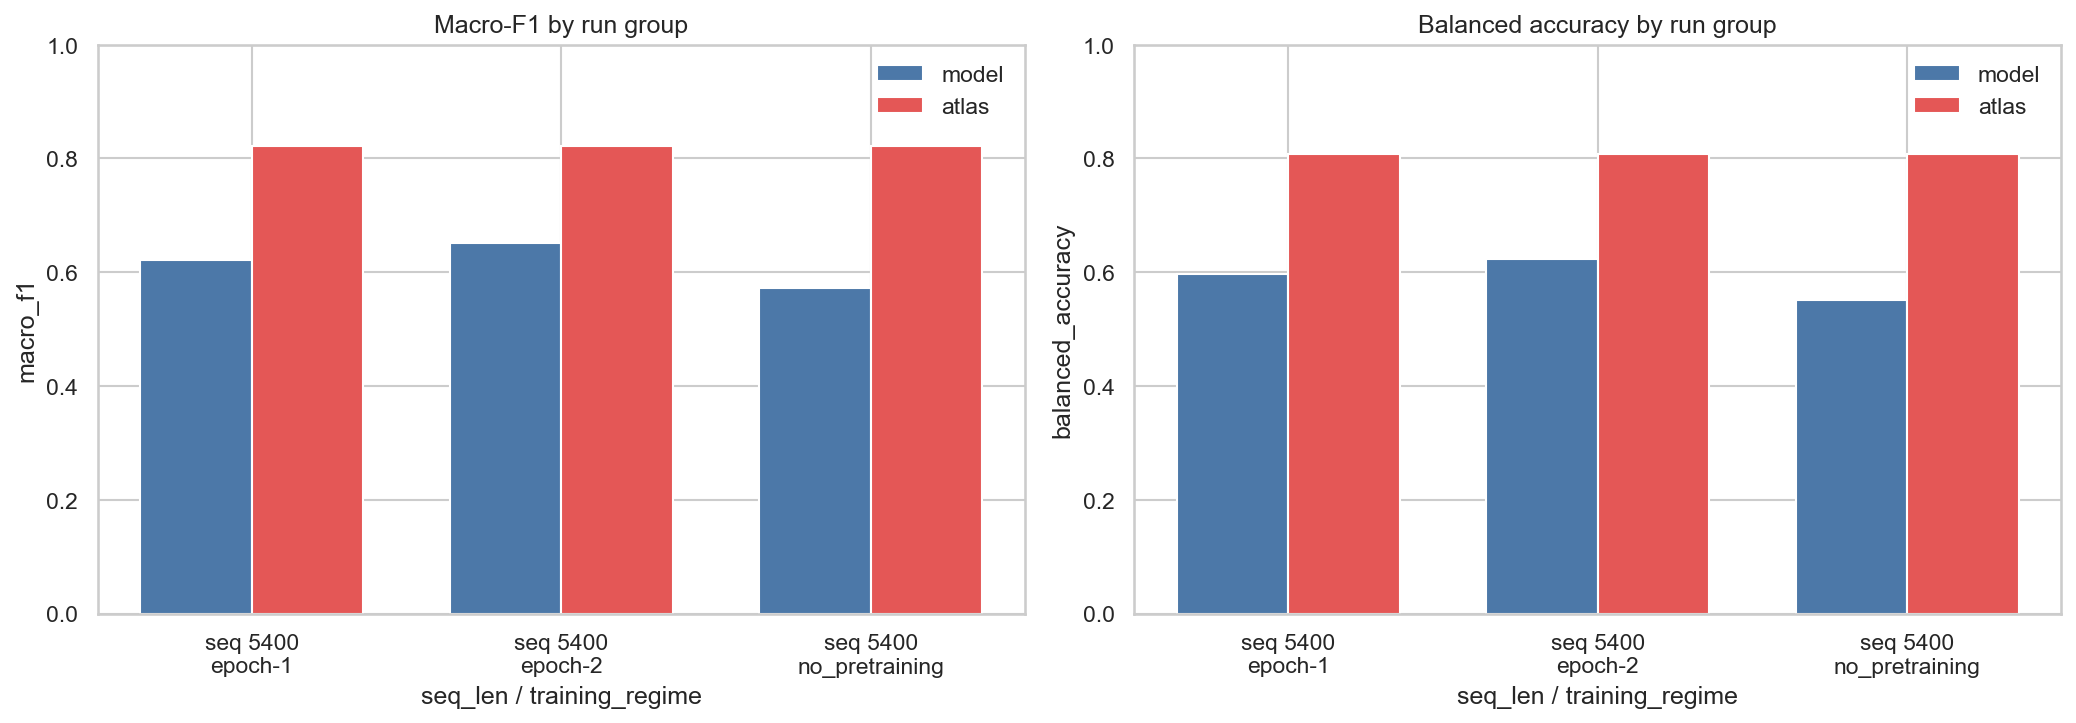

### macro_f1_model_vs_atlas_scatter.png

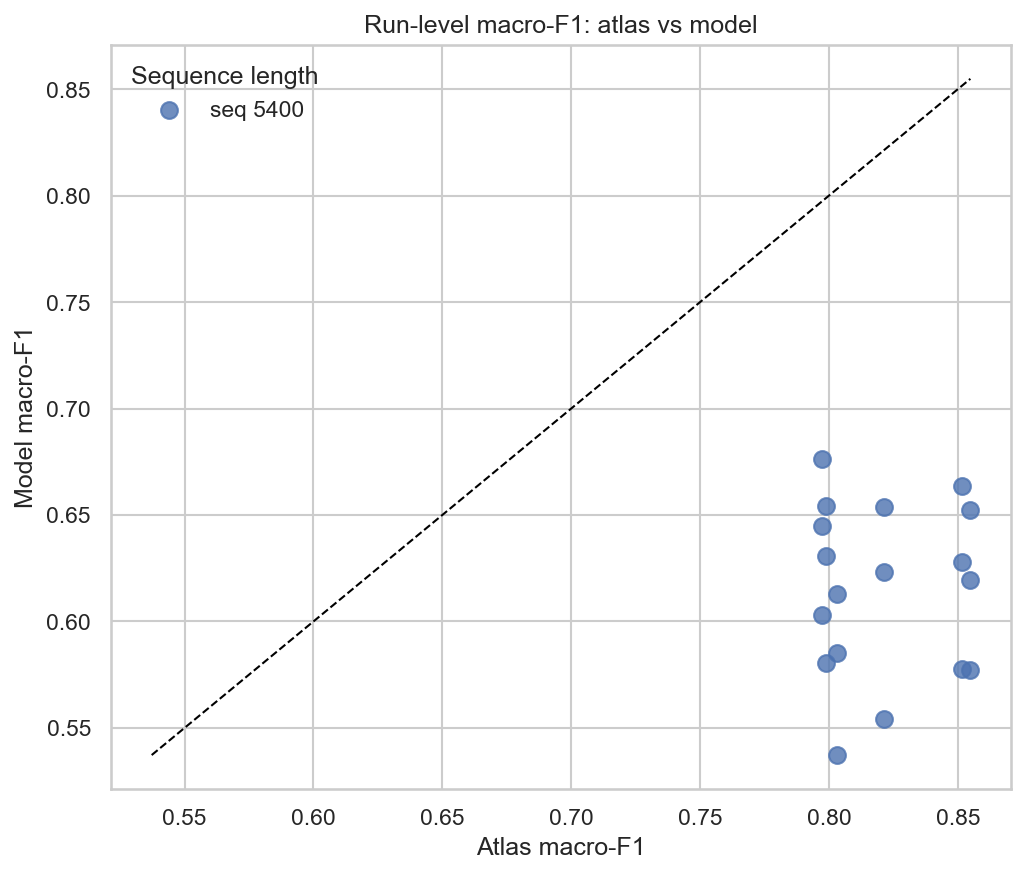

### overall_confusion_heatmaps.png

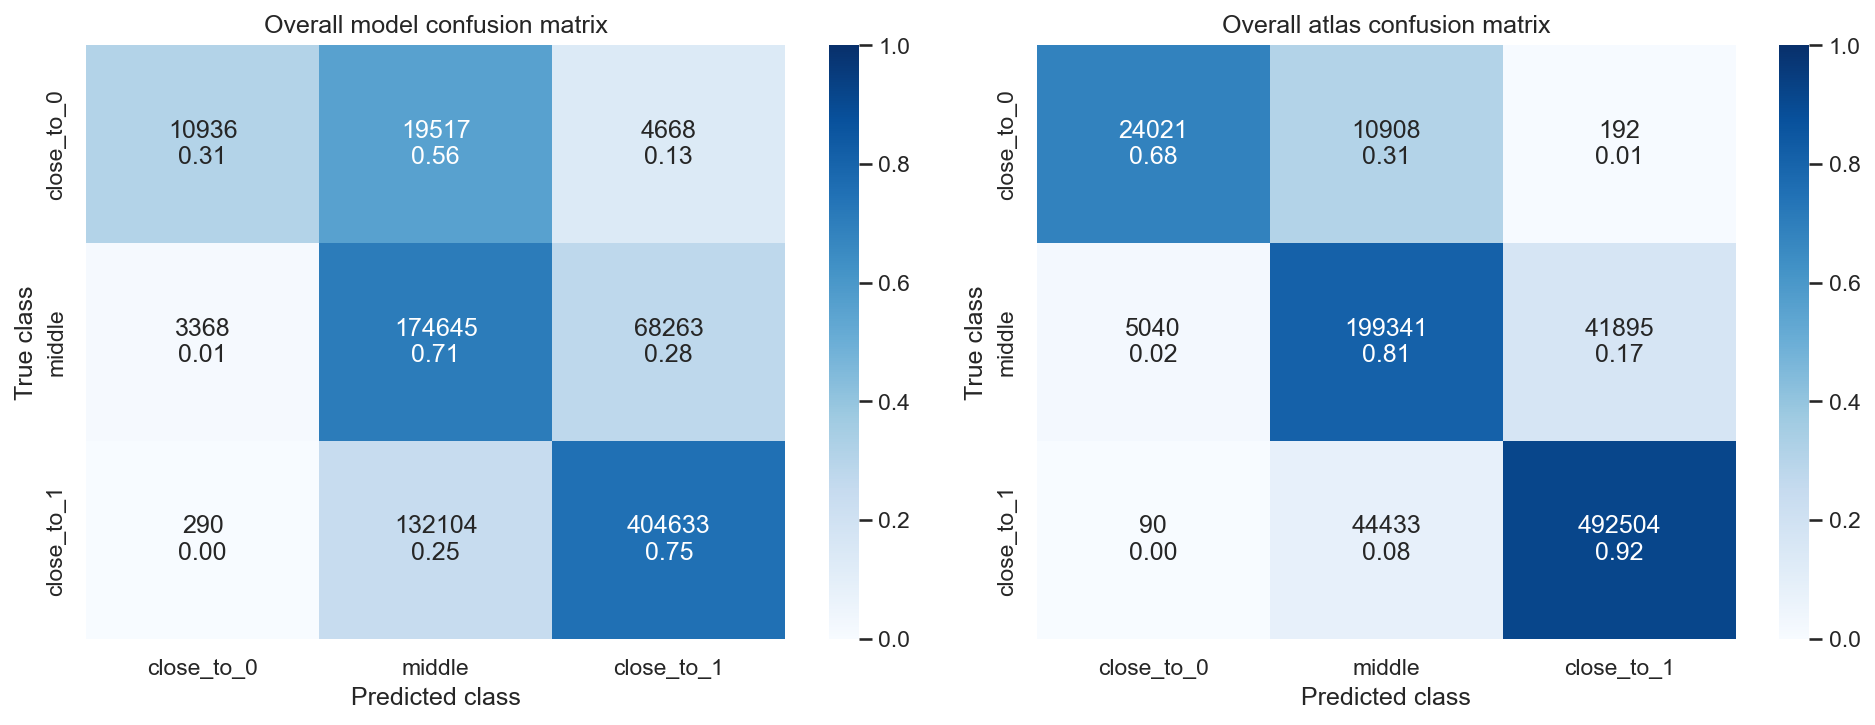

### overall_label_class_support.png

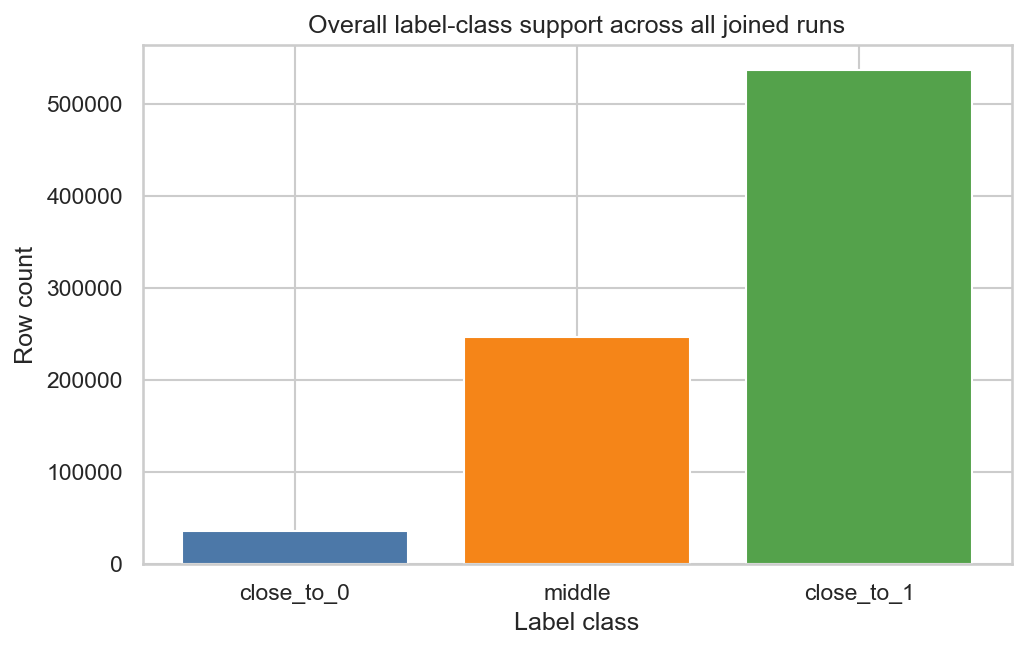

### per_class_recall_heatmaps.png

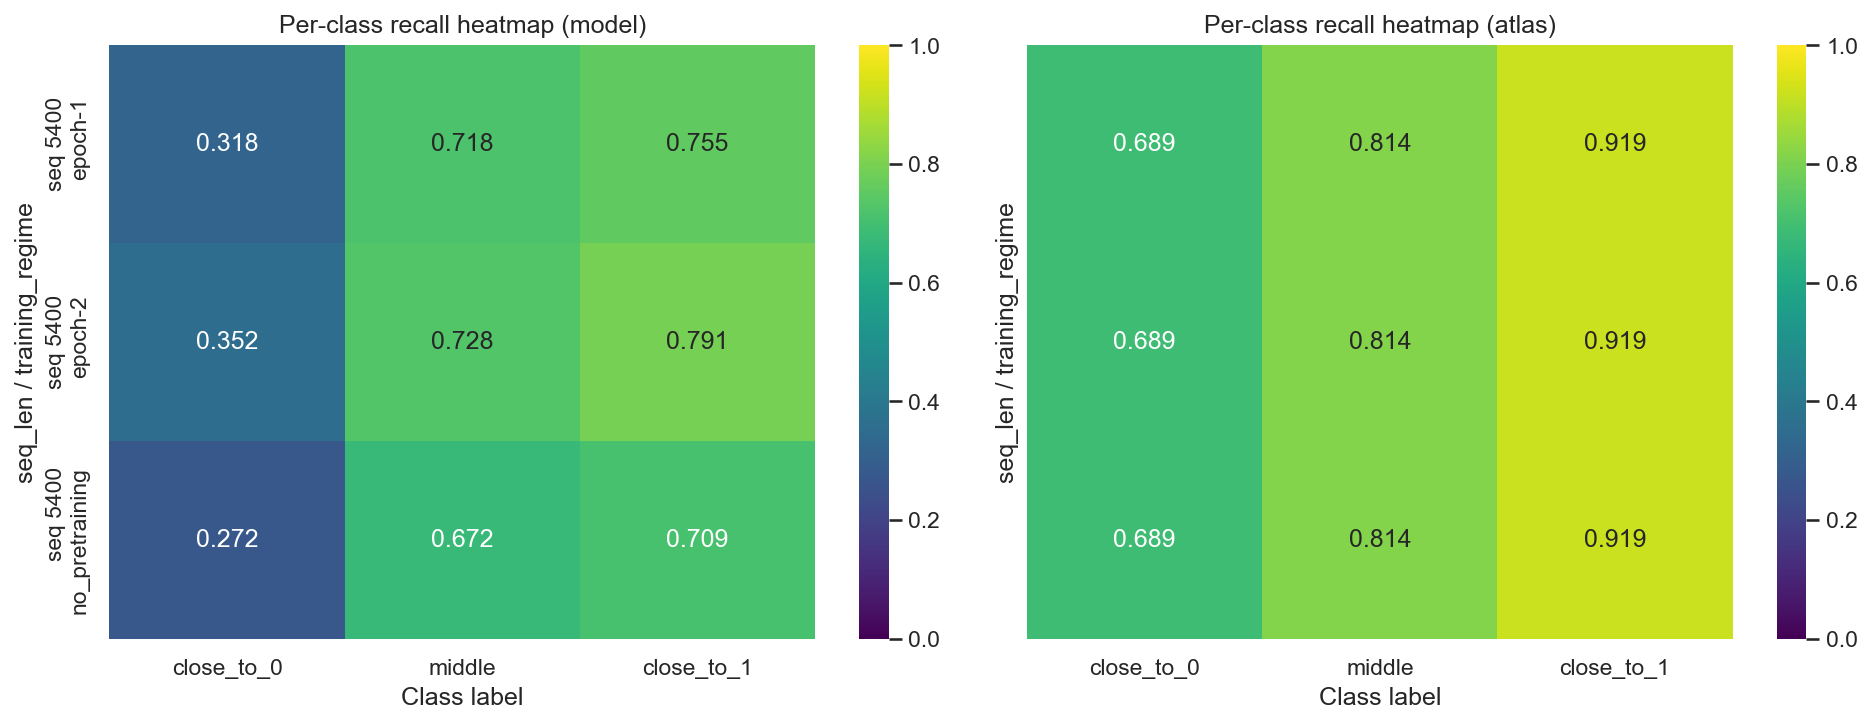

In [13]:
from IPython.display import Image, Markdown, display

figure_paths = sorted(FIGURES_DIR.glob("*.png"))
if not figure_paths:
    raise FileNotFoundError(f"No figures found in {FIGURES_DIR}")

print(f"Displaying {len(figure_paths)} figures from {FIGURES_DIR}")
for figure_path in figure_paths:
    display(Markdown(f"### {figure_path.name}"))
    display(Image(filename=str(figure_path)))
